<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Making a toy dataset (two concentric differently coloured circles)

from sklearn.datasets import make_circles
X_np,y_np= make_circles(n_samples= 1000, noise=0.03, random_state=42)

In [ ]:
# Let's make a DataFrame for the data

import pandas as pd
circles= pd.DataFrame({"X1": X_np[:,0], "X2": X_np[:,1], "label": y_np})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [ ]:
print(circles.label.value_counts())
# we have balanced data, cool!

label
1    500
0    500
Name: count, dtype: int64


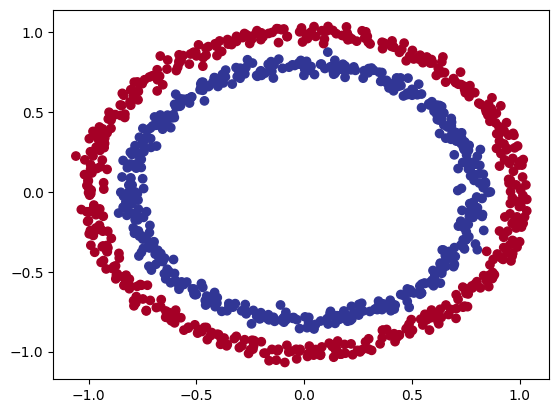

In [ ]:
# Let's vizualise the data first

import matplotlib.pyplot as plt
plt.scatter(x=X_np[:,0], y=X_np[:,1], c=y_np, cmap= plt.cm.RdYlBu)

In [ ]:
# Let's split the data to train & test
#first we need to turn data into tensors (for pytorch)

import torch
X= torch.from_numpy(X_np).type(torch.float)
y= torch.from_numpy(y_np).type(torch.float)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,
                                                   test_size=0.2,
                                                   random_state=42)


In [ ]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
# Building a linear model (weak for our problem)
from torch import nn

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1= nn.Linear(in_features=2, out_features=5)
    self.layer_2= nn.Linear(in_features=5, out_features=1)

  def forward(self,X):
    return self.layer_2(self.layer_1(X))

model_0= CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# let's set the training components

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
loss_fn= nn.BCEWithLogitsLoss()

def accuracy(y_true,y_pred):
  corrects= torch.eq(y_true,y_pred).sum().item()
  return (corrects/len(y_true))*100

In [ ]:
# Let's set a training loop
epochs= 100

# Let's put the data to target device first
X_train, X_test= X_train.to(device), X_test.to(device)
y_train, y_test= y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  model_0.train()
  y_logits= model_0(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))
  train_loss= loss_fn(y_logits, y_train)
  train_acc= accuracy(y_train, y_pred)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits= model_0(X_test).squeeze()
    test_pred= torch .round(torch.sigmoid(test_logits))
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy(y_test, test_pred)

    if epoch %10 ==0:
      print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.71772 | Train Acc: 50.00% | Test Loss: 0.72117 | Test Acc: 50.00%
Epoch: 10 | Train Loss: 0.70136 | Train Acc: 44.12% | Test Loss: 0.70725 | Test Acc: 43.50%
Epoch: 20 | Train Loss: 0.69662 | Train Acc: 47.62% | Test Loss: 0.70294 | Test Acc: 48.00%
Epoch: 30 | Train Loss: 0.69500 | Train Acc: 49.50% | Test Loss: 0.70109 | Test Acc: 47.00%
Epoch: 40 | Train Loss: 0.69429 | Train Acc: 50.12% | Test Loss: 0.69996 | Test Acc: 47.50%
Epoch: 50 | Train Loss: 0.69389 | Train Acc: 50.12% | Test Loss: 0.69911 | Test Acc: 46.50%
Epoch: 60 | Train Loss: 0.69364 | Train Acc: 50.50% | Test Loss: 0.69842 | Test Acc: 47.00%
Epoch: 70 | Train Loss: 0.69346 | Train Acc: 50.75% | Test Loss: 0.69786 | Test Acc: 47.00%
Epoch: 80 | Train Loss: 0.69334 | Train Acc: 50.50% | Test Loss: 0.69739 | Test Acc: 46.50%
Epoch: 90 | Train Loss: 0.69325 | Train Acc: 51.00% | Test Loss: 0.69700 | Test Acc: 45.50%


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

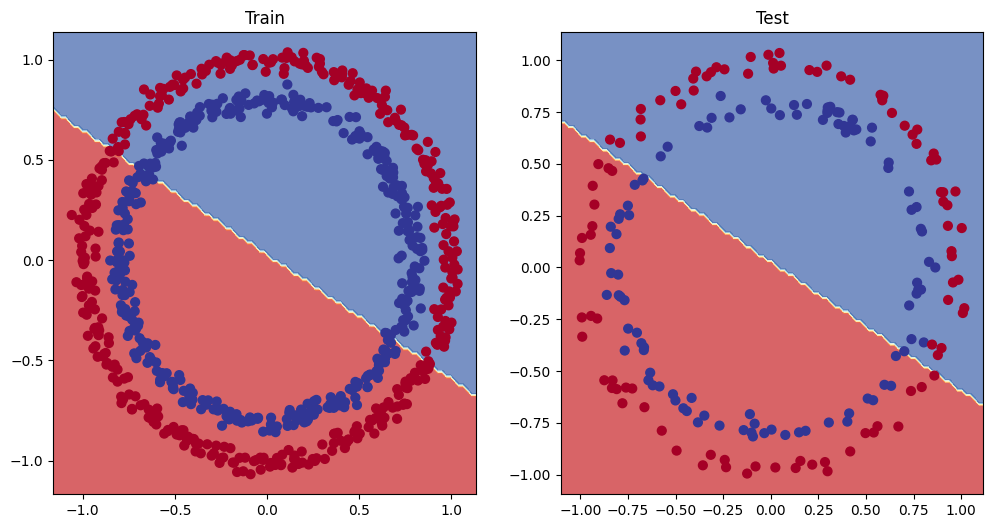

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
# building a better model (adding activation functions + expanding the NN overall)

class CircleModelV1(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer_1= nn.Linear(in_features= 2, out_features=10)
    self.layer_2= nn.Linear(in_features= 10, out_features=10)
    self.layer_3= nn.Linear(in_features= 10, out_features=1)
    self.relu =nn.ReLU()

  def forward(self, X):
    X= self.layer_1(X)
    X= self.relu(X)
    X= self.layer_2(X)
    X= self.relu(X)
    X= self.layer_3(X)
    return X

Model_1=CircleModelV1().to(device)
Model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# we need a new optimizer ofc
loss_fn= nn.BCEWithLogitsLoss()
optimizer_1= torch.optim.SGD(params=Model_1.parameters(), lr=0.1)

In [ ]:
y_pred= Model_1(X_test).squeeze()
y_pred.shape, y_test.shape

(torch.Size([200]), torch.Size([200]))

In [ ]:
# Fitting the model
torch.manual_seed(42)
epochs= 1000

#this step is already done previously, but for clarity we'll have it again
X_train, X_test= X_train.to(device), X_test.to(device)
y_train, y_test= y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  Model_1.train()
  y_logits=Model_1(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))
  train_loss= loss_fn(y_logits, y_train)
  train_acc= accuracy(y_true=y_train, y_pred=y_pred)

  optimizer_1.zero_grad()
  train_loss.backward()
  optimizer_1.step()

  Model_1.eval()
  with torch.inference_mode():
    test_logits= Model_1(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy(y_true=y_test, y_pred=test_pred)

    if epoch %100 ==0:
      print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.69648 | Train Acc: 47.12% | Test Loss: 0.69920 | Test Acc: 46.50
Epoch: 100 | Train Loss: 0.69237 | Train Acc: 50.38% | Test Loss: 0.69511 | Test Acc: 47.50
Epoch: 200 | Train Loss: 0.69028 | Train Acc: 51.25% | Test Loss: 0.69302 | Test Acc: 49.00
Epoch: 300 | Train Loss: 0.68756 | Train Acc: 52.62% | Test Loss: 0.69061 | Test Acc: 49.50
Epoch: 400 | Train Loss: 0.68319 | Train Acc: 62.00% | Test Loss: 0.68690 | Test Acc: 57.50
Epoch: 500 | Train Loss: 0.67563 | Train Acc: 70.12% | Test Loss: 0.68059 | Test Acc: 61.50
Epoch: 600 | Train Loss: 0.66276 | Train Acc: 76.00% | Test Loss: 0.67033 | Test Acc: 68.00
Epoch: 700 | Train Loss: 0.64106 | Train Acc: 78.50% | Test Loss: 0.65408 | Test Acc: 70.00
Epoch: 800 | Train Loss: 0.60324 | Train Acc: 80.00% | Test Loss: 0.62482 | Test Acc: 75.00
Epoch: 900 | Train Loss: 0.53591 | Train Acc: 84.12% | Test Loss: 0.56830 | Test Acc: 78.50


In [ ]:
# Let's test the model and make predictions
Model_1.eval()
with torch.inference_mode():
  test_pred= torch.round(torch.sigmoid(Model_1(X_test).squeeze()))
  acc= accuracy(y_true=y_test, y_pred=test_pred)
  print(f"Model 1 test accuracy: {acc:.2f}%")
Comparison=pd.DataFrame({"y_test": y_test.cpu(), "y_pred": test_pred.cpu()})
Comparison


Model 1 test accuracy: 84.00%


,y_test,y_pred
0,1.0,1.0
1,0.0,0.0
2,1.0,1.0
3,0.0,0.0
4,1.0,1.0
...,...,...
195,0.0,0.0
196,1.0,1.0
197,0.0,0.0
198,1.0,1.0


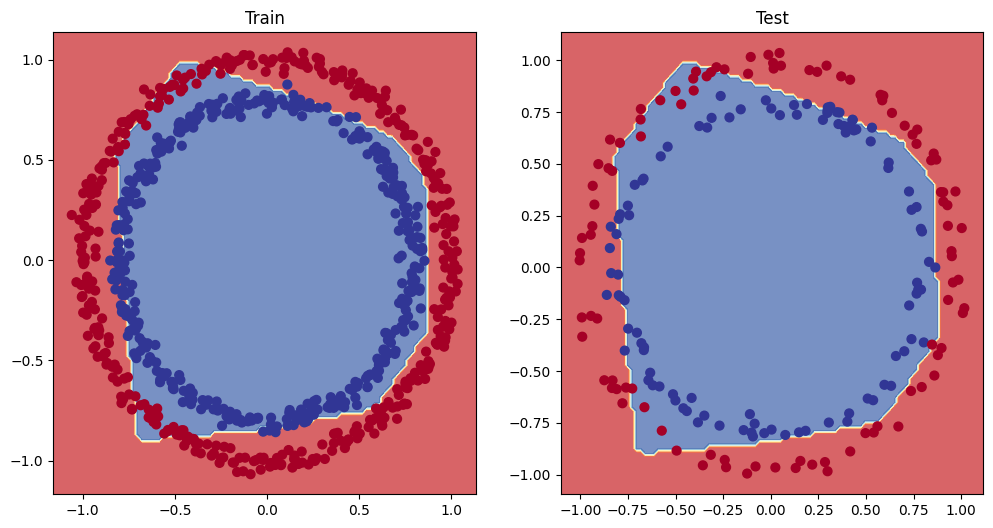

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_1, X_test, y_test)

**-> It's clear that the non-linear is fitting better to the circular data**